**Purpose:** Export news sentiment as a portfolio feature (as_feature_data.parquet).

**Inputs:** `as_feature_data.parquet`

**Outputs:** `as_feature_data.parquet`

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [1]:
import pandas as pd
import json
import os
import numpy as np

dfs = [x for x in os.listdir() if x.endswith(".parquet")]

df_concat = pd.read_parquet(dfs[0])

for file in dfs[1:]:
    df = pd.read_parquet(file)
    df_concat = pd.concat([df_concat, df], ignore_index=True)

df_concat["data"] = df_concat["data"].apply(json.loads)

Total errors: 7403 out of 351648 rows (2.11%)


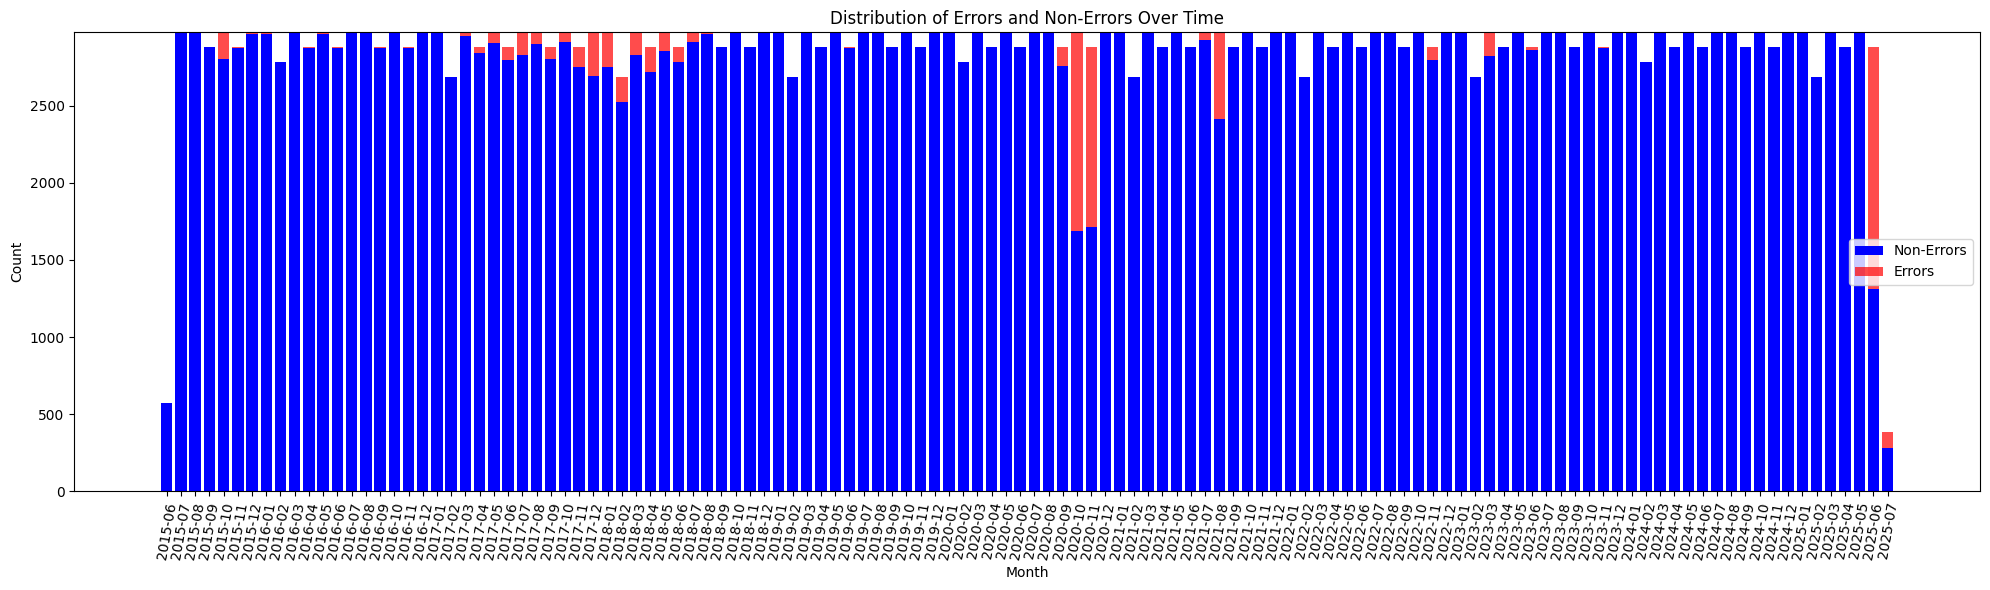

In [2]:
import matplotlib.pyplot as plt

dates = df_concat["timestamp"].unique()
if len(dates) != len(df_concat):
    print("Warning: There are duplicate dates in the dataset.")

months = sorted(pd.to_datetime(df_concat["timestamp"]).dt.to_period("M").unique().astype(str))

all_error_counts = {x: 0 for x in months}
all_non_error_counts = {x: 0 for x in months}

errors_total = 0
for i, row in df_concat.iterrows():
    date = row["timestamp"]
    month = pd.to_datetime(date).to_period("M").strftime("%Y-%m")
    if "error" in row["data"]:
        all_error_counts[month] += 1
        errors_total += 1
    else:
        all_non_error_counts[month] += 1

print(f"Total errors: {errors_total} out of {len(df_concat)} rows ({errors_total / len(df_concat) * 100:.2f}%)")

plt.figure(figsize=(20, 6))
plt.bar(all_non_error_counts.keys(), all_non_error_counts.values(), label="Non-Errors", color="blue")
plt.bar(all_error_counts.keys(), all_error_counts.values(), bottom=list(all_non_error_counts.values()), label="Errors", color="red", alpha=0.7)
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Distribution of Errors and Non-Errors Over Time")
plt.xticks(rotation=80)
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
df_concat

,timestamp,data
0,20170928053000,"{'timestamp': '20170928053000', 'Communication..."
1,20180126150000,"{'timestamp': '20180126150000', 'Communication..."
2,20160407154500,"{'timestamp': '20160407154500', 'Communication..."
3,20190410170000,"{'timestamp': '20190410170000', 'Communication..."
4,20160214201500,"{'timestamp': '20160214201500', 'Communication..."
...,...,...
351643,20250704230000,"{'timestamp': '20250704230000', 'Communication..."
351644,20250704231500,"{'timestamp': '20250704231500', 'Communication..."
351645,20250704233000,"{'timestamp': '20250704233000', 'Communication..."
351646,20250704234500,"{'timestamp': '20250704234500', 'Communication..."


In [4]:
df_concat.iloc[0,1]

{'timestamp': '20170928053000',
 'Communication Services': {'neutral': [0.667, 0.784]},
 'Consumer Discretionary': {'neutral': [0.686, 0.798, 0.81]},
 'Consumer Staples': {'neutral': [0.72, 0.906, 0.676, 0.846, 0.867]},
 'Energy': {'neutral': [0.81, 0.886, 0.515], 'negative': [0.892]},
 'Financials': {'neutral': [0.779, 0.862, 0.802]},
 'Health Care': {'neutral': [0.956, 0.715, 0.847]},
 'Industrials': {'neutral': [0.731, 0.695, 0.901, 0.831, 0.848, 0.869],
  'positive': [0.524]},
 'Information Technology': {'neutral': [0.948,
   0.608,
   0.864,
   0.632,
   0.709,
   0.822,
   0.805,
   0.83],
  'positive': [0.824]},
 'Materials': {'neutral': [0.717, 0.909, 0.822, 0.821, 0.858, 0.878],
  'positive': [0.755]},
 'Real Estate': {'neutral': [0.779, 0.931, 0.926, 0.75, 0.887, 0.903]},
 'Utilities': {'neutral': [0.772, 0.931, 0.77, 0.893, 0.908]}}

In [5]:
errors_qtd = {}
errors_timestamps = {}

for i, row in df_concat.iterrows():
    if "error" in row["data"]:
        error_message = row["data"]["error"].split(":")[-1]

        if error_message.startswith(" Expected 27 fields in line"):
            error_message = "Expected 27 fields in line ..., saw ..."
        elif error_message == " File is not a zip file\n":
            error_message = "File is not a zip file"

        if error_message not in errors_qtd:
            errors_qtd[error_message] = 0
            errors_timestamps[error_message] = []
        errors_qtd[error_message] += 1
        errors_timestamps[error_message].append(row["timestamp"])
        
errors_qtd

{'File is not a zip file': 7350,
 'Expected 27 fields in line ..., saw ...': 40,
 ' No columns to parse from file\n': 10,
 ' Buffer overflow caught - possible malformed input file.\n\n': 3}

In [6]:
existent_keys = set()
are_errors_alone = set()

for i, row in df_concat.iterrows():
    if "error" in row["data"]:
        for key in row["data"]:
            are_errors_alone.add(key)

    for key in row["data"]:
        existent_keys.add(key)

print("Keys that appear in error rows:", are_errors_alone)
print("Keys that exist:", existent_keys)

Keys that appear in error rows: {'error', 'timestamp'}
Keys that exist: {'Consumer Discretionary', 'Utilities', 'error', 'Energy', 'Consumer Staples', 'Financials', 'Materials', 'Real Estate', 'Communication Services', 'Industrials', 'Health Care', 'timestamp', 'Information Technology'}


In [7]:
for i, row in df_concat.iterrows():
    if str(row["timestamp"]) != str(row["data"]["timestamp"]):
        print(f"Timestamp mismatch at index {i}: row timestamp = {row['timestamp']}, data timestamp = {row['data']['timestamp']}")

problemas:

[X] 15 minutos para dias -> before market open goes to the past day, else stays in the same day ; implies timezone handling: GDELT is UTC (http://data.gdeltproject.org/documentation/GDELT-Event_Codebook-V2.0.pdf), and NYSE opens at 9.30am US/Eastern (https://www.nyse.com/trade/hours-calendars)

[ ] non trading days -> use lag and forget : up to 3 days before (longest non-trading period streak, based on our downloaded data)

[X] data structure -> ETF_sentiment_t as column name and value being the list of classifications confidences for that day and that ETF

[X] missing timestamps / errors -> if more 20% of the timestamps (15min intervals) are missing/error for a day (segment of the day), set it to NaN / invalid

[X] falta de dados antes do inicio e depois do fim por causa dos lags -> facil ir buscar dados mais antigos e mais recentes, ou seja, antes de 2015/07/01 por exemplo

In [8]:
df = df_concat.copy()

In [9]:
assets = ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']

sectors = {
    "Materials": "XLB",
    "Communication Services": "XLC",
    "Energy": "XLE",
    "Financials": "XLF",
    "Industrials": "XLI",
    "Information Technology": "XLK",
    "Consumer Staples": "XLP",
    "Real Estate": "XLRE",
    "Utilities": "XLU",
    "Health Care": "XLV",
    "Consumer Discretionary": "XLY"
}

sentiments = {
    "negative",
    "neutral",
    "positive"
}

In [10]:
# Set timestamp to datetime with UTC timezone
df['timestamp_utc'] = pd.to_datetime(df['timestamp'], utc=True)

# Convert to New York time
df['timestamp_et'] = df['timestamp_utc'].dt.tz_convert('America/New_York')

# Spell current day's date
df['date_et'] = df['timestamp_et'].dt.date

# Set day bucket based on time (pre-market goes to previous day, else stays in the same day)
def set_day_bucket(row):
    if row['timestamp_et'].time() < pd.to_datetime("09:30").time():
        return row['date_et'] - pd.Timedelta(days=1)
    else:
        return row['date_et']
df['day_bucket'] = df.apply(set_day_bucket, axis=1)

# Drop aux columns used for processing
df.drop(columns=['timestamp', 'timestamp_utc', 'timestamp_et', 'date_et'], inplace=True)

df

,data,day_bucket
0,"{'timestamp': '20170928053000', 'Communication...",2017-09-27
1,"{'timestamp': '20180126150000', 'Communication...",2018-01-26
2,"{'timestamp': '20160407154500', 'Communication...",2016-04-07
3,"{'timestamp': '20190410170000', 'Communication...",2019-04-10
4,"{'timestamp': '20160214201500', 'Communication...",2016-02-14
...,...,...
351643,"{'timestamp': '20250704230000', 'Communication...",2025-07-04
351644,"{'timestamp': '20250704231500', 'Communication...",2025-07-04
351645,"{'timestamp': '20250704233000', 'Communication...",2025-07-04
351646,"{'timestamp': '20250704234500', 'Communication...",2025-07-04


In [11]:
data = {}

for i, row in df.iterrows():
    day = row['day_bucket']
    if day not in data:
        data[day] = {
            f"{asset}_news_sentiment_{sentiment}": [] for asset in assets for sentiment in sentiments
        }
        data[day]["valid"] = 0
        data[day]["invalid"] = 0

    if "error" in row["data"]:
        data[day]["invalid"] += 1
    
    else:
        data[day]["valid"] += 1
        for sector in row["data"]:
            if sector != "timestamp":
                for sentiment in row["data"][sector]:
                    asset = sectors[sector]
                    key = f"{asset}_news_sentiment_{sentiment}"
                    data[day][key].extend(row["data"][sector][sentiment])
    
data = pd.DataFrame.from_dict(data, orient='index')

data["valid_ratio"] = (data["valid"] / (data["valid"] + data["invalid"])) > 0.8

print("Count of valid vs invalid days:")
print(data.value_counts("valid_ratio"))

data.loc[data["valid_ratio"] == False, :] = np.float64(np.nan)

data.drop(columns=["valid", "invalid", "valid_ratio"], inplace=True)

Count of valid vs invalid days:
valid_ratio
True     3577
False      87
Name: count, dtype: int64


/var/folders/sz/96b_h5gn3y33k0c7jsvrstmm0000gn/T/ipykernel_52138/4114790971.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.loc[data["valid_ratio"] == False, :] = np.float64(np.nan)


In [12]:
data

,XLB_news_sentiment_neutral,XLB_news_sentiment_negative,XLB_news_sentiment_positive,XLC_news_sentiment_neutral,XLC_news_sentiment_negative,XLC_news_sentiment_positive,XLE_news_sentiment_neutral,XLE_news_sentiment_negative,XLE_news_sentiment_positive,XLF_news_sentiment_neutral,...,XLRE_news_sentiment_positive,XLU_news_sentiment_neutral,XLU_news_sentiment_negative,XLU_news_sentiment_positive,XLV_news_sentiment_neutral,XLV_news_sentiment_negative,XLV_news_sentiment_positive,XLY_news_sentiment_neutral,XLY_news_sentiment_negative,XLY_news_sentiment_positive
2017-09-27,"[0.717, 0.909, 0.822, 0.821, 0.858, 0.878, 0.6...","[0.928, 0.882, 0.498]","[0.755, 0.516, 0.624, 0.563, 0.472, 0.626, 0.5...","[0.667, 0.784, 0.667, 0.784, 0.635, 0.473, 0.6...","[0.772, 0.839, 0.885, 0.89, 0.672, 0.955, 0.43...","[0.951, 0.732, 0.496, 0.613, 0.709, 0.562, 0.4...","[0.81, 0.886, 0.515, 0.81, 0.886, 0.515, 0.533...","[0.892, 0.918, 0.829, 0.874, 0.608, 0.585, 0.9...","[0.721, 0.774, 0.613, 0.865, 0.609, 0.538, 0.8...","[0.779, 0.862, 0.802, 0.779, 0.862, 0.751, 0.8...",...,"[0.727, 0.896, 0.705, 0.548, 0.478, 0.608, 0.6...","[0.772, 0.931, 0.77, 0.893, 0.908, 0.892, 0.74...","[0.583, 0.772, 0.915, 0.665, 0.515, 0.827, 0.5...","[0.743, 0.792, 0.746, 0.527, 0.867, 0.904, 0.5...","[0.956, 0.715, 0.847, 0.685, 0.674, 0.748, 0.7...","[0.521, 0.646, 0.695, 0.666, 0.666, 0.778, 0.7...","[0.715, 0.579, 0.869, 0.884, 0.638, 0.686, 0.7...","[0.686, 0.798, 0.81, 0.686, 0.798, 0.686, 0.79...","[0.76, 0.763, 0.878, 0.886, 0.731, 0.774, 0.87...","[0.827, 0.824, 0.59, 0.902, 0.694, 0.55, 0.95,..."
2018-01-26,"[0.905, 0.549, 0.812, 0.905, 0.812, 0.812, 0.8...","[0.518, 0.91, 0.666, 0.698, 0.835, 0.865, 0.86...","[0.832, 0.567, 0.854, 0.624, 0.624, 0.39, 0.68...","[0.463, 0.618, 0.768, 0.768, 0.869, 0.514, 0.5...","[0.585, 0.466, 0.358, 0.844, 0.594, 0.861, 0.8...","[0.563, 0.563, 0.563, 0.563, 0.563, 0.628, 0.5...","[0.579, 0.946, 0.611, 0.935, 0.75, 0.946, 0.92...","[0.858, 0.879, 0.75, 0.637, 0.822, 0.858, 0.80...","[0.51, 0.583, 0.515, 0.715, 0.765, 0.784, 0.49...","[0.572, 0.446, 0.567, 0.67, 0.916, 0.567, 0.6,...",...,"[0.51, 0.564, 0.519, 0.709, 0.469, 0.709, 0.70...","[0.734, 0.737, 0.734, 0.571, 0.447, 0.703, 0.7...","[0.948, 0.601, 0.948, 0.558, 0.948, 0.472, 0.5...","[0.607, 0.543, 0.506, 0.802, 0.488, 0.506, 0.6...","[0.629, 0.842, 0.46, 0.473, 0.879, 0.843, 0.47...","[0.621, 0.515, 0.49, 0.616, 0.875, 0.907, 0.72...","[0.69, 0.64, 0.585, 0.74, 0.39, 0.521, 0.521, ...","[0.64, 0.447, 0.877, 0.555, 0.489, 0.645, 0.67...","[0.68, 0.905, 0.928, 0.905, 0.565, 0.574, 0.90...","[0.549, 0.549, 0.549, 0.549, 0.549, 0.549, 0.5..."
2016-04-07,"[0.941, 0.65, 0.877, 0.875, 0.483, 0.544, 0.70...","[0.964, 0.964, 0.626, 0.589, 0.589, 0.848, 0.5...","[0.668, 0.535, 0.92, 0.846, 0.674, 0.577, 0.85...","[0.773, 0.651, 0.49, 0.529, 0.807, 0.541, 0.52...","[0.712, 0.712, 0.771, 0.97, 0.915, 0.918, 0.58...","[0.886, 0.906, 0.831, 0.663, 0.702, 0.657, 0.8...","[0.6, 0.639, 0.878, 0.557, 0.694, 0.892, 0.862...","[0.712, 0.797, 0.883, 0.849, 0.899, 0.568, 0.6...","[0.59, 0.783, 0.83, 0.518, 0.633, 0.825, 0.841...","[0.784, 0.86, 0.69, 0.656, 0.676, 0.708, 0.886...",...,"[0.601, 0.808, 0.835, 0.706, 0.781, 0.597, 0.6...","[0.955, 0.721, 0.672, 0.553, 0.94, 0.653, 0.58...","[0.848, 0.743, 0.861, 0.872, 0.896, 0.896, 0.6...","[0.617, 0.821, 0.846, 0.722, 0.798, 0.616, 0.6...","[0.817, 0.817, 0.943, 0.567, 0.74, 0.639, 0.88...","[0.472, 0.585, 0.764, 0.869, 0.832, 0.571, 0.6...","[0.877, 0.73, 0.6, 0.51, 0.668, 0.48, 0.741, 0...","[0.788, 0.788, 0.674, 0.762, 0.362, 0.658, 0.4...","[0.812, 0.8, 0.55, 0.435, 0.59, 0.833, 0.473, ...","[0.738, 0.525, 0.483, 0.483, 0.811, 0.773, 0.5..."
2019-04-10,"[0.869, 0.64, 0.501, 0.741, 0.501, 0.774, 0.88...","[0.754, 0.754, 0.936, 0.725, 0.539, 0.754, 0.9...","[0.833, 0.646, 0.52, 0.782, 0.478, 0.68, 0.725...","[0.805, 0.799, 0.499, 0.802, 0.743, 0.682, 0.4...","[0.64, 0.529, 0.404, 0.685, 0.64, 0.656, 0.778...","[0.652, 0.74, 0.849, 0.748, 0.35

In [ ]:
# data.to_parquet("as_feature_data.parquet")

In [15]:
import pandas as pd

df = pd.read_parquet("as_feature_data.parquet")
df

,XLB_news_sentiment_neutral,XLB_news_sentiment_negative,XLB_news_sentiment_positive,XLC_news_sentiment_neutral,XLC_news_sentiment_negative,XLC_news_sentiment_positive,XLE_news_sentiment_neutral,XLE_news_sentiment_negative,XLE_news_sentiment_positive,XLF_news_sentiment_neutral,...,XLRE_news_sentiment_positive,XLU_news_sentiment_neutral,XLU_news_sentiment_negative,XLU_news_sentiment_positive,XLV_news_sentiment_neutral,XLV_news_sentiment_negative,XLV_news_sentiment_positive,XLY_news_sentiment_neutral,XLY_news_sentiment_negative,XLY_news_sentiment_positive
2017-09-27,"[0.717, 0.909, 0.822, 0.821, 0.858, 0.878, 0.6...","[0.928, 0.882, 0.498]","[0.755, 0.516, 0.624, 0.563, 0.472, 0.626, 0.5...","[0.667, 0.784, 0.667, 0.784, 0.635, 0.473, 0.6...","[0.772, 0.839, 0.885, 0.89, 0.672, 0.955, 0.43...","[0.951, 0.732, 0.496, 0.613, 0.709, 0.562, 0.4...","[0.81, 0.886, 0.515, 0.81, 0.886, 0.515, 0.533...","[0.892, 0.918, 0.829, 0.874, 0.608, 0.585, 0.9...","[0.721, 0.774, 0.613, 0.865, 0.609, 0.538, 0.8...","[0.779, 0.862, 0.802, 0.779, 0.862, 0.751, 0.8...",...,"[0.727, 0.896, 0.705, 0.548, 0.478, 0.608, 0.6...","[0.772, 0.931, 0.77, 0.893, 0.908, 0.892, 0.74...","[0.583, 0.772, 0.915, 0.665, 0.515, 0.827, 0.5...","[0.743, 0.792, 0.746, 0.527, 0.867, 0.904, 0.5...","[0.956, 0.715, 0.847, 0.685, 0.674, 0.748, 0.7...","[0.521, 0.646, 0.695, 0.666, 0.666, 0.778, 0.7...","[0.715, 0.579, 0.869, 0.884, 0.638, 0.686, 0.7...","[0.686, 0.798, 0.81, 0.686, 0.798, 0.686, 0.79...","[0.76, 0.763, 0.878, 0.886, 0.731, 0.774, 0.87...","[0.827, 0.824, 0.59, 0.902, 0.694, 0.55, 0.95,..."
2018-01-26,"[0.905, 0.549, 0.812, 0.905, 0.812, 0.812, 0.8...","[0.518, 0.91, 0.666, 0.698, 0.835, 0.865, 0.86...","[0.832, 0.567, 0.854, 0.624, 0.624, 0.39, 0.68...","[0.463, 0.618, 0.768, 0.768, 0.869, 0.514, 0.5...","[0.585, 0.466, 0.358, 0.844, 0.594, 0.861, 0.8...","[0.563, 0.563, 0.563, 0.563, 0.563, 0.628, 0.5...","[0.579, 0.946, 0.611, 0.935, 0.75, 0.946, 0.92...","[0.858, 0.879, 0.75, 0.637, 0.822, 0.858, 0.80...","[0.51, 0.583, 0.515, 0.715, 0.765, 0.784, 0.49...","[0.572, 0.446, 0.567, 0.67, 0.916, 0.567, 0.6,...",...,"[0.51, 0.564, 0.519, 0.709, 0.469, 0.709, 0.70...","[0.734, 0.737, 0.734, 0.571, 0.447, 0.703, 0.7...","[0.948, 0.601, 0.948, 0.558, 0.948, 0.472, 0.5...","[0.607, 0.543, 0.506, 0.802, 0.488, 0.506, 0.6...","[0.629, 0.842, 0.46, 0.473, 0.879, 0.843, 0.47...","[0.621, 0.515, 0.49, 0.616, 0.875, 0.907, 0.72...","[0.69, 0.64, 0.585, 0.74, 0.39, 0.521, 0.521, ...","[0.64, 0.447, 0.877, 0.555, 0.489, 0.645, 0.67...","[0.68, 0.905, 0.928, 0.905, 0.565, 0.574, 0.90...","[0.549, 0.549, 0.549, 0.549, 0.549, 0.549, 0.5..."
2016-04-07,"[0.941, 0.65, 0.877, 0.875, 0.483, 0.544, 0.70...","[0.964, 0.964, 0.626, 0.589, 0.589, 0.848, 0.5...","[0.668, 0.535, 0.92, 0.846, 0.674, 0.577, 0.85...","[0.773, 0.651, 0.49, 0.529, 0.807, 0.541, 0.52...","[0.712, 0.712, 0.771, 0.97, 0.915, 0.918, 0.58...","[0.886, 0.906, 0.831, 0.663, 0.702, 0.657, 0.8...","[0.6, 0.639, 0.878, 0.557, 0.694, 0.892, 0.862...","[0.712, 0.797, 0.883, 0.849, 0.899, 0.568, 0.6...","[0.59, 0.783, 0.83, 0.518, 0.633, 0.825, 0.841...","[0.784, 0.86, 0.69, 0.656, 0.676, 0.708, 0.886...",...,"[0.601, 0.808, 0.835, 0.706, 0.781, 0.597, 0.6...","[0.955, 0.721, 0.672, 0.553, 0.94, 0.653, 0.58...","[0.848, 0.743, 0.861, 0.872, 0.896, 0.896, 0.6...","[0.617, 0.821, 0.846, 0.722, 0.798, 0.616, 0.6...","[0.817, 0.817, 0.943, 0.567, 0.74, 0.639, 0.88...","[0.472, 0.585, 0.764, 0.869, 0.832, 0.571, 0.6...","[0.877, 0.73, 0.6, 0.51, 0.668, 0.48, 0.741, 0...","[0.788, 0.788, 0.674, 0.762, 0.362, 0.658, 0.4...","[0.812, 0.8, 0.55, 0.435, 0.59, 0.833, 0.473, ...","[0.738, 0.525, 0.483, 0.483, 0.811, 0.773, 0.5..."
2019-04-10,"[0.869, 0.64, 0.501, 0.741, 0.501, 0.774, 0.88...","[0.754, 0.754, 0.936, 0.725, 0.539, 0.754, 0.9...","[0.833, 0.646, 0.52, 0.782, 0.478, 0.68, 0.725...","[0.805, 0.799, 0.499, 0.802, 0.743, 0.682, 0.4...","[0.64, 0.529, 0.404, 0.685, 0.64, 0.656, 0.778...","[0.652, 0.74, 0.849, 0.748, 0.35